In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw6.ipynb")

# CPSC 330 - Applied Machine Learning 

## Homework 6: Clustering
### Associated lectures: [Lectures 14 and 15](https://ubc-cs.github.io/cpsc330-2025W2/#lecture-schedule-tentative)

**Due date: See [deliverable due dates](https://ubc-cs.github.io/cpsc330-2025W2/#deliverable-due-dates-tentative)**.

## Imports <a name="im"></a>

In [2]:
import os
from hashlib import sha1

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline
pd.set_option("display.max_colwidth", 0)

<br><br><br><br>

<!-- BEGIN QUESTION -->

<div class="alert alert-info">
    
## Instructions
rubric={points}

You will earn points for following these instructions and successfully submitting your work on Gradescope.  

### Group wotk instructions

**You may work with a partner on this homework and submit your assignment as a group.** Below are some instructions on working as a group.  
- The maximum group size is 2.
  
- Use group work as an opportunity to collaborate and learn new things from each other. 
- Be respectful to each other and make sure you understand all the concepts in the assignment well. 
- It's your responsibility to make sure that the assignment is submitted by one of the group members before the deadline. 
- You can find the instructions on how to do group submission on Gradescope [here](https://help.gradescope.com/article/m5qz2xsnjy-student-add-group-members).
- If you would like to use late tokens for the homework, all group members must have the necessary late tokens available. Please note that the late tokens will be counted for all members of the group.   


### General submission instructions

- Please **read carefully
[Use of Generative AI policy](https://ubc-cs.github.io/cpsc330-2025W2/syllabus#use-of-generative-ai-in-the-course)** before starting the homework assignment. 
- **Run all cells before submitting:** Go to `Kernel -> Restart Kernel and Clear All Outputs`, then select `Run -> Run All Cells`. This ensures your notebook runs cleanly from start to finish without errors.
  
- **Submit your files on Gradescope.**  
   - Upload only your `.ipynb` file **with outputs displayed** and any required output files.
     
   - Do **not** submit other files from your repository.  
   - If you need help, see the [Gradescope Student Guide](https://lthub.ubc.ca/guides/gradescope-student-guide/).  
- **Check that outputs render properly.**  
   - Make sure all plots and outputs appear in your submission.
     
   - If your `.ipynb` file is too large and doesn't render on Gradescope, also upload a PDF version so the TAs can view your work.
- **Keep execution order clean.**  
   - Execution numbers must start at "1" and increase in order.
     
   - Notebooks without visible outputs may not be graded.  
   - Out-of-order or missing execution numbers may result in mark deductions.  
- **Follow course submission guidelines:** Review the [CPSC 330 homework instructions](https://ubc-cs.github.io/cpsc330-2025W2/docs/homework-instructions) for detailed guidance on completing and submitting assignments. 
   
</div>

_Points:_ 4

<!-- END QUESTION -->

<br><br><br><br>

## Exercise 1: Document clustering warm-up
<hr>

In this homework, we will explore a popular application of clustering called [**document clustering**](https://en.wikipedia.org/wiki/Document_clustering). A large amount of unlabeled text data is available out there (e.g., news, recipes, online Q&A, tweets), and clustering is a commonly used technique to organize this data in a meaningful way. 

As a warm up, in this exercise you will cluster sentences from a toy corpus. Later in the homework you will work with a real corpus. 

The code below extracts introductory sentences of Wikipedia articles on a set of queries. To run the code successfully, you will need the `wikipedia` package installed in the course environment. 

```
conda activate cpsc330
conda install -c conda-forge wikipedia
```


**Your tasks:**

Run the code below which 
- extracts content of Wikipedia articles on a set of queries
- tokenizes the text (i.e., separates sentences) and 
- stores the 2nd sentence in each article as a document representing that article

> Feel free to experiment with Wikipedia queries of your choice. But stick to the provided list for the final submission so that it's easier for the TAs to grade your submission.

> For tokenization we are using the `nltk` package. If you do not have this package in the course environment, you will have to install it.

```
conda activate cpsc330
conda install -c anaconda nltk
```

Even if you have the package installed via the course `conda` environment, you might have to download `nltk` pre-trained models, which can be done with the code below.

In [3]:
import nltk

nltk.download("punkt")
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\zhouz\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\zhouz\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [4]:
import wikipedia
import string
from nltk.tokenize import sent_tokenize, word_tokenize

queries = [
    "Artificial Intelligence",
    "Deep learning",
    "Unsupervised learning",
    "Quantum Computer",
    "Environmental protection",
    "Climate Change",
    "Renewable Energy",
    "Biodiversity",
    "French Cuisine",
    "Bread food",
    "Dumpling food",
]
wiki_dict = {"wiki query": [], "text": [], "n_words": []}
remove_tokens = list(string.punctuation) + ['``', '’', '`', 'br', '"', "”", "''", "'s", "(", ")", "[", "]"]

# Running this code might take some time.
for query in queries:
    try:
        # Attempt to fetch the page content
        page_content = wikipedia.page(query).content
    except wikipedia.exceptions.PageError:
        print(f"Page not found for query: {query}. Skipping...")
        continue
    except wikipedia.exceptions.DisambiguationError as e:
        print(f"Query: {query} led to a disambiguation page. Choosing the first option: {e.options[0]}")
        page_content = wikipedia.page(e.options[0]).content

    text = sent_tokenize(page_content)[0]
    tokenized = word_tokenize(text)
    text_pp = [token.lower() for token in tokenized if token.lower() not in remove_tokens]
    wiki_dict["n_words"].append(len(text_pp))
    wiki_dict["text"].append(" ".join(text_pp))
    wiki_dict["wiki query"].append(query)

wiki_df = pd.DataFrame(wiki_dict)
wiki_df

,wiki query,text,n_words
0,Artificial Intelligence,artificial intelligence ai is the capability of computational systems to perform tasks typically associated with human intelligence such as learning reasoning problem-solving perception and decision-making,25
1,Deep learning,in machine learning deep learning dl focuses on utilizing multilayered neural networks to perform tasks such as classification regression and representation learning,22
2,Unsupervised learning,in machine learning supervised learning sl is a type of machine learning paradigm where an algorithm learns to map input data to a specific output based on example input-output pairs,30
3,Quantum Computer,a quantum computer is a real or theoretical computer that exploits superposed and entangled states,15
4,Environmental protection,environmental protection or environment protection refers to the taking of measures to protecting the natural environment prevent pollution and maintain ecological balance,22
5,Climate Change,present-day climate change includes both global warming — the ongoing increase in global average temperature — and its wider effects on earth climate system,24
6,Renewable Energy,renewable energy also called green energy is energy made from renewable natural resources that are replenished on a human timescale,20
7,Biodiversity,biodiversity is the variability of life on earth,8
8,French Cuisine,french cuisine is the cooking traditions and practices of france,10
9,Bread food,bread is a baked food product made from water flour and often yeast,13


Our toy corpus has six toy documents (`text` column in the dataframe) extracted from Wikipedia queries. 

<br><br>

<!-- BEGIN QUESTION -->

### 1.1 How many clusters? 
rubric={reasoning}

<div class="alert alert-info">

**Your tasks:**

- If tasked with manually clustering documents from this toy corpus, how many clusters would you identify, and what labels would you assign to each cluster?
</div>

<div class="alert alert-warning">

Solution_1.1
    
</div>

_Points:_ 1

Number of clusters: 4

Cluster 1: Artificial Intelligence / Machine Learning
Cluster 2: Environment / Climate
Cluster 3: Food / Cuisine
Cluster 4: Quantum Computing

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

### 1.2 K-Means with bag-of-words representation 
rubric={accuracy}

In the lecture, we explored how **data representation significantly impacts clustering quality**. We saw that replacing a **flattened image representation** with feature vectors extracted from **pre-trained models** greatly improved clustering results.  

What about text data? In previous machine learning courses, we have used the **bag-of-words (BoW) representation** to numerically encode text, where each document is represented with a vector of word frequencies. 

In this exercise, you will **cluster documents** using this **simplistic text representation**.  

<div class="alert alert-info">

**Your tasks:**

1. Use [`CountVectorizer`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) with its **default settings** to transform the `text` column in `wiki_df` into a numerical representation.  

2. Use [`KMeans`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) to cluster the encoded documents and store the cluster labels in `kmeans_bow_labels`.  
   - Set `random_state=42` for **reproducibility**.
     
   - Use the **number of clusters** (`n_clusters`) identified in the **previous exercise**.  
</div>

<div class="alert alert-warning">

Solution_1.2
    
</div>

_Points:_ 2

In [5]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(wiki_df["text"])


kmeans = KMeans(n_clusters=4, random_state=42)


In [6]:
kmeans_bow_labels = kmeans.fit_predict(X)

In [7]:
wiki_df["bow_kmeans"] = kmeans_bow_labels
wiki_df

,wiki query,text,n_words,bow_kmeans
0,Artificial Intelligence,artificial intelligence ai is the capability of computational systems to perform tasks typically associated with human intelligence such as learning reasoning problem-solving perception and decision-making,25,1
1,Deep learning,in machine learning deep learning dl focuses on utilizing multilayered neural networks to perform tasks such as classification regression and representation learning,22,2
2,Unsupervised learning,in machine learning supervised learning sl is a type of machine learning paradigm where an algorithm learns to map input data to a specific output based on example input-output pairs,30,2
3,Quantum Computer,a quantum computer is a real or theoretical computer that exploits superposed and entangled states,15,1
4,Environmental protection,environmental protection or environment protection refers to the taking of measures to protecting the natural environment prevent pollution and maintain ecological balance,22,0
5,Climate Change,present-day climate change includes both global warming — the ongoing increase in global average temperature — and its wider effects on earth climate system,24,1
6,Renewable Energy,renewable energy also called green energy is energy made from renewable natural resources that are replenished on a human timescale,20,3
7,Biodiversity,biodiversity is the variability of life on earth,8,1
8,French Cuisine,french cuisine is the cooking traditions and practices of france,10,1
9,Bread food,bread is a baked food product made from water flour and often yeast,13,1


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

### 1.3 K-Means with sentence embedding representation
rubric={accuracy}

In the previous exercise, you may have noticed that clustering results were suboptimal. While the bag-of-words (BoW) representation is useful, it has significant limitations. It does not capture word order or context effectively.  

To improve text representation, we can use pre-trained models, similar to those used for image data, to extract richer, context-aware embeddings through transfer learning. In this lab, we will use the **pre-trained model** `'all-MiniLM-L6-v2'`, available via the [Sentence Transformers](https://www.sbert.net/index.html) package.  

This deep learning model generates **dense, fixed-length vector representations** of sentences, capturing **semantic meaning and contextual information**. These representations are particularly effective for **clustering and semantic similarity tasks**. If you're interested in exploring more **pre-trained models**, refer to the [full list here](https://www.sbert.net/docs/pretrained_models.html). We will explore these representations further in **DSCI 575**.  

<div class="alert alert-info">

**Your tasks:**

1. Run the code below to create sentence embedding representation of documents in our toy corpus.
   
3. Apply `KMeans` to the **sentence embeddings** (`emb_sents`) and store the cluster labels in `kmeans_emb_labels`. Use the following parameters:  
    - `random_state=42` (for reproducibility)
      
    - `n_clusters`=the number of clusters you identified in 1.1

Note
- The code below might throw a warning. You may ignore it for the purpose of this lab. 
</div>

In [8]:

from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer("all-MiniLM-L6-v2")



c:\Users\zhouz\miniforge3\envs\cpsc330-fresh\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [9]:
emb_sents = embedder.encode(wiki_df["text"].tolist())
emb_sent_df = pd.DataFrame(emb_sents, index=wiki_df.index)
emb_sent_df

,0,1,2,3,4,5,6,7,8,9,...,374,375,376,377,378,379,380,381,382,383
0,-0.005857,-0.004795,-0.000976,0.011121,0.005294,-0.061630,0.062072,0.033673,-0.035251,0.074072,...,0.088312,-0.006600,0.036511,-0.020797,-0.002082,0.058263,0.061880,0.097383,0.058155,-0.052016
1,-0.122905,-0.092450,0.085379,-0.009761,0.001422,0.069146,-0.046654,-0.069960,-0.021858,-0.052803,...,0.065826,0.031800,-0.021052,-0.113772,-0.013588,0.056793,-0.013167,0.009044,-0.011912,-0.011387
2,-0.056721,-0.049697,-0.014780,0.022572,0.051773,0.007456,0.008632,-0.074847,-0.065573,-0.027284,...,0.014761,-0.022392,0.021360,-0.107016,0.020530,0.045678,0.052755,0.005430,0.022018,-0.010994
3,-0.071932,-0.006760,-0.083421,0.022650,-0.116415,0.034988,-0.055792,-0.045055,-0.017993,0.020915,...,-0.076031,-0.016973,-0.054588,-0.020448,-0.016833,0.120573,0.027863,0.076044,0.060111,0.057609
4,-0.012700,0.101830,0.066676,-0.007987,0.140040,0.041627,0.035495,-0.050723,-0.037633,0.055886,...,-0.042105,-0.038883,0.018268,0.009920,0.028208,0.052759,-0.009605,-0.004518,0.060853,0.057709
5,-0.014444,0.022869,0.145982,0.054865,0.085204,-0.014689,-0.102757,0.016853,-0.023799,0.021148,...,0.011778,0.016817,-0.020041,0.006375,0.055428,0.076868,-0.047152,-0.114797,-0.056382,0.022349
6,-0.044869,0.076882,-0.012749,0.033335,0.067894,-0.002326,0.031620,-0.021576,0.046619,0.005089,...,-0.021575,-0.017596,-0.069995,0.004461,-0.040409,-0.043067,0.044042,-0.050977,0.056506,0.048708
7,0.027806,0.077117,0.015402,-0.013544,0.043216,0.048124,0.027763,-0.022999,0.049303,0.009686,...,0.014946,-0.020896,0.022283,-0.012311,0.014079,0.028085,0.025272,-0.015233,-0.014879,-0.064280
8,0.026616,-0.019929,-0.008049,-0.025907,-0.055372,0.011235,-0.024538,-0.065724,0.058374,-0.062895,...,-0.059513,0.077446,-0.059827,-0.021454,0.088102,-0.127180,-0.031399,0.120572,0.072373,-0.058336
9,-0.014786,0.055887,-0.020880,0.005313,-0.025037,0.040479,0.035260,0.024938,0.017546,0.072433,...,-0.082098,0.037856,-0.020007,-0.087252,0.058163,-0.044187,-0.030253,-0.080385,0.075614,-0.070403


<div class="alert alert-warning">

Solution_1.3
    
</div>

_Points:_ 2

In [10]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)


In [11]:
kmeans_emb_labels = kmeans.fit_predict(emb_sents)

In [12]:
wiki_df["emb_kmeans"] = kmeans_emb_labels
wiki_df

,wiki query,text,n_words,bow_kmeans,emb_kmeans
0,Artificial Intelligence,artificial intelligence ai is the capability of computational systems to perform tasks typically associated with human intelligence such as learning reasoning problem-solving perception and decision-making,25,1,2
1,Deep learning,in machine learning deep learning dl focuses on utilizing multilayered neural networks to perform tasks such as classification regression and representation learning,22,2,2
2,Unsupervised learning,in machine learning supervised learning sl is a type of machine learning paradigm where an algorithm learns to map input data to a specific output based on example input-output pairs,30,2,2
3,Quantum Computer,a quantum computer is a real or theoretical computer that exploits superposed and entangled states,15,1,2
4,Environmental protection,environmental protection or environment protection refers to the taking of measures to protecting the natural environment prevent pollution and maintain ecological balance,22,0,0
5,Climate Change,present-day climate change includes both global warming — the ongoing increase in global average temperature — and its wider effects on earth climate system,24,1,0
6,Renewable Energy,renewable energy also called green energy is energy made from renewable natural resources that are replenished on a human timescale,20,3,0
7,Biodiversity,biodiversity is the variability of life on earth,8,1,0
8,French Cuisine,french cuisine is the cooking traditions and practices of france,10,1,1
9,Bread food,bread is a baked food product made from water flour and often yeast,13,1,1


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

### 1.4 DBSCAN with sentence embedding representation and cosine distance  
rubric={accuracy}

Now, let's apply [`DBSCAN`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html) to our toy dataset.  

Unlike K-Means, which relies on Euclidean distance due to its use of centroids, DBSCAN allows us to experiment with different distance metrics. For text data, [**cosine similarity**](https://scikit-learn.org/stable/modules/metrics.html#cosine-similarity) (or its complement, **cosine distance**) is often more effective than Euclidean distance.  

The **cosine distance** between two vectors $u$ and $v$ is defined as: 

$$distance_{cosine}(u,v) = 1 - (\frac{u \cdot v}{\left\lVert u\right\rVert_2 \left\lVert v\right\rVert_2})$$

<div class="alert alert-info">

**Your tasks:**

- Apply **DBSCAN** to cluster documents encoded with **sentence embeddings** (`emb_sents`) and store the cluster labels in `dbscan_emb_labels`.
    
- Set `metric='cosine'` to use **cosine distance** for clustering.
- Tune the **hyperparameters** `eps` and `min_samples` to obtain meaningful clusters, as the default values are unlikely to work well on this dataset.  

**Notes for tuning the hyperparameters:**

- Start by examining the minimum, maximum, and mean cosine distances in the dataset. You can compute pairwise cosine distances using the package imported below.
  
- Experiment with a range of `eps` values and print the number of clusters and their sizes for each value.
- Select the `eps` value that produces the desired number of clusters.


</div>

In [13]:
from sklearn.metrics.pairwise import cosine_distances

<div class="alert alert-warning">

Solution_1.4
    
</div>

_Points:_ 4

In [14]:

dist_matrix = cosine_distances(emb_sents)


dist_vals = dist_matrix[np.triu_indices_from(dist_matrix, k=1)]

print("min:", dist_vals.min())
print("max:", dist_vals.max())
print("mean:", dist_vals.mean())

min: 0.5178395
max: 1.0320184
mean: 0.89426917


In [15]:
from sklearn.cluster import DBSCAN


for eps in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]:
    db = DBSCAN(eps=eps, min_samples=2, metric="cosine")
    labels = db.fit_predict(emb_sents)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    unique, counts = np.unique(labels, return_counts=True)
    print("eps =", eps, "| clusters =", n_clusters, "| sizes =", dict(zip(unique, counts)))

eps = 0.1 | clusters = 0 | sizes = {np.int64(-1): np.int64(11)}
eps = 0.2 | clusters = 0 | sizes = {np.int64(-1): np.int64(11)}
eps = 0.3 | clusters = 0 | sizes = {np.int64(-1): np.int64(11)}
eps = 0.4 | clusters = 0 | sizes = {np.int64(-1): np.int64(11)}
eps = 0.5 | clusters = 0 | sizes = {np.int64(-1): np.int64(11)}
eps = 0.6 | clusters = 1 | sizes = {np.int64(-1): np.int64(8), np.int64(0): np.int64(3)}


In [16]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.4, min_samples=2, metric="cosine")


In [17]:
dbscan_emb_labels = dbscan.fit_predict(emb_sents)

In [18]:
wiki_df["emb_dbscan"] = dbscan_emb_labels
wiki_df

,wiki query,text,n_words,bow_kmeans,emb_kmeans,emb_dbscan
0,Artificial Intelligence,artificial intelligence ai is the capability of computational systems to perform tasks typically associated with human intelligence such as learning reasoning problem-solving perception and decision-making,25,1,2,-1
1,Deep learning,in machine learning deep learning dl focuses on utilizing multilayered neural networks to perform tasks such as classification regression and representation learning,22,2,2,-1
2,Unsupervised learning,in machine learning supervised learning sl is a type of machine learning paradigm where an algorithm learns to map input data to a specific output based on example input-output pairs,30,2,2,-1
3,Quantum Computer,a quantum computer is a real or theoretical computer that exploits superposed and entangled states,15,1,2,-1
4,Environmental protection,environmental protection or environment protection refers to the taking of measures to protecting the natural environment prevent pollution and maintain ecological balance,22,0,0,-1
5,Climate Change,present-day climate change includes both global warming — the ongoing increase in global average temperature — and its wider effects on earth climate system,24,1,0,-1
6,Renewable Energy,renewable energy also called green energy is energy made from renewable natural resources that are replenished on a human timescale,20,3,0,-1
7,Biodiversity,biodiversity is the variability of life on earth,8,1,0,-1
8,French Cuisine,french cuisine is the cooking traditions and practices of france,10,1,1,-1
9,Bread food,bread is a baked food product made from water flour and often yeast,13,1,1,-1


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

### 1.5 Hierarchical clustering with sentence embedding representation
rubric={accuracy}

<div class="alert alert-info">

**Your tasks:**

Apply hierarchical clustering on `emb_sents`. In particular
1. Create and show a dendrogram with `complete` linkage and `metric='cosine'` on this toy dataset.

3. Create flat clusters using `fcluster` with appropriate hyperparameters and store cluster labels to `hier_emb_labels` variable below.

</div>

<div class="alert alert-warning">

Solution_1.5
    
</div>

_Points:_ 3

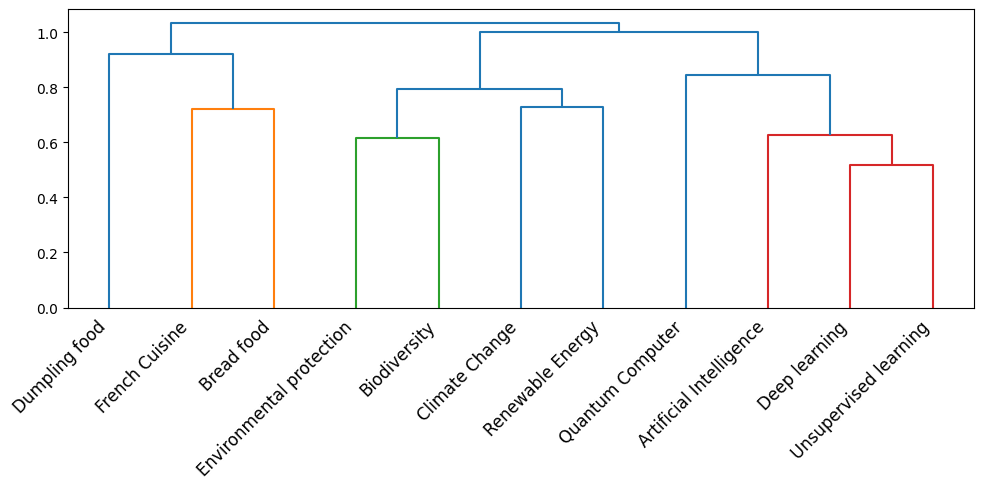

In [19]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt

Z = linkage(emb_sents, method="complete", metric="cosine")

plt.figure(figsize=(10, 5))
dendrogram(Z, labels=wiki_df["wiki query"].tolist())
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [20]:
hier_emb_labels = fcluster(Z, t=4, criterion="maxclust")

In [21]:
wiki_df["emb_hierarchical"] = hier_emb_labels
wiki_df

,wiki query,text,n_words,bow_kmeans,emb_kmeans,emb_dbscan,emb_hierarchical
0,Artificial Intelligence,artificial intelligence ai is the capability of computational systems to perform tasks typically associated with human intelligence such as learning reasoning problem-solving perception and decision-making,25,1,2,-1,4
1,Deep learning,in machine learning deep learning dl focuses on utilizing multilayered neural networks to perform tasks such as classification regression and representation learning,22,2,2,-1,4
2,Unsupervised learning,in machine learning supervised learning sl is a type of machine learning paradigm where an algorithm learns to map input data to a specific output based on example input-output pairs,30,2,2,-1,4
3,Quantum Computer,a quantum computer is a real or theoretical computer that exploits superposed and entangled states,15,1,2,-1,4
4,Environmental protection,environmental protection or environment protection refers to the taking of measures to protecting the natural environment prevent pollution and maintain ecological balance,22,0,0,-1,3
5,Climate Change,present-day climate change includes both global warming — the ongoing increase in global average temperature — and its wider effects on earth climate system,24,1,0,-1,3
6,Renewable Energy,renewable energy also called green energy is energy made from renewable natural resources that are replenished on a human timescale,20,3,0,-1,3
7,Biodiversity,biodiversity is the variability of life on earth,8,1,0,-1,3
8,French Cuisine,french cuisine is the cooking traditions and practices of france,10,1,1,-1,1
9,Bread food,bread is a baked food product made from water flour and often yeast,13,1,1,-1,1


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

### 1.6 Discussion
rubric={reasoning}

<div class="alert alert-info">

**Your tasks:**

Reflect on and discuss the clustering results of the methods you explored in the previous exercises, focusing on the following points:    
- effect of input representation on clustering results

- whether the clustering results match with your intuitions and the challenges associated with getting the desired clustering results with each method

</div>

<div class="alert alert-warning">

Solution_1.6
    
</div>

_Points:_ 4

The clustering results change depending on the representation. 
BoW only counts words so it does not capture semantic meaning very well. 
Sentence embeddings work better because they capture similarity between texts.

With embeddings, KMeans and hierarchical clustering group similar topics like AI, environment and food together, which makes sense. 
DBSCAN was harder to tune since the eps value affects results a lot and many points become noise.

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

### 1.7 Visualizing clusters
rubric={points:4}


One approach to working with unlabeled data is visualization. That said, our data is high-dimensional, making it challenging to visualize. Take sentence embedding representation as an example: each instance is depicted in 768 dimensions. To visualize such high-dimensional data, we can employ dimensionality reduction techniques to extract the most significant 2 or 3 components, and then visualize this low-dimensional data.

Given data as a `numpy` array and corresponding cluster assignments, the `plot_umap_clusters` function below transforms the data by applying dimensionality reduction technique called [UMAP](https://umap-learn.readthedocs.io/en/latest/) to it and plots the transformed data with different colours for different clusters. 

> *Note: At this point we are using this function only for visualization and you are not expected to understand the UMAP part.* 

You'll have to install the `umap-learn` package in the course conda environment either with `conda` or `pip`, as described in the [documentation](https://umap-learn.readthedocs.io/en/latest/index.html). 

```
> conda activate cpsc330
> conda install -c conda-forge umap-learn
```
or

```
> conda activate cpsc330
> pip install umap-learn 
```

If you get an error with the import below try

```
pip install --upgrade numba umap-learn
```

<div class="alert alert-info">
    
**Your tasks:**

1. Visualize the clusters created by the methods above using `plot_umap_clusters` function below. In other words, visualize clusters identified by each of the methods below. 
    - K-Means with bag-of-words representation 
    - K-Means with sentence embedding representation
    - DBSCAN with sentence embedding representation 
    - Flat cluster of hierarchical clustering with sentence embedding representation
</div>

In [22]:
import umap

In [23]:
def plot_umap_clusters(
    data,
    cluster_labels,
    raw_texts=None,
    show_labels=False,
    point_size=50,
    n_neighbors=15,
    title="UMAP Visualization",
    ignore_noise=False,
):
    """
    Perform dimensionality reduction using UMAP and visualize the resulting clusters.

    Parameters
    ----------
    data : np.ndarray
        Feature matrix to be reduced.
    cluster_labels : array-like
        Cluster label for each data point.
    raw_texts : list of str, optional
        Original texts corresponding to the data points (used when show_labels=True).
    show_labels : bool, default=False
        Whether to annotate points with text labels.
    point_size : int, default=50
        Size of the scatterplot points.
    n_neighbors : int, default=15
        Number of neighbors used in UMAP.
    title : str, default="UMAP Visualization"
        Title of the plot.
    ignore_noise : bool, default=False
        Whether to exclude points labeled as noise (-1).

    Returns
    -------
    None
    """
    reducer = umap.UMAP(n_neighbors=n_neighbors, random_state=42)
    embedding = reducer.fit_transform(data)

    df = pd.DataFrame(embedding, columns=["dim1", "dim2"])
    df["cluster"] = cluster_labels

    if ignore_noise:
        df = df[df["cluster"] != -1]

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.set_title(title)

    scatter = ax.scatter(
        df["dim1"], df["dim2"],
        c=df["cluster"], cmap="tab20b", s=point_size
    )

    ax.legend(*scatter.legend_elements(), title="Clusters", loc="best")

    if show_labels and raw_texts is not None:
        for (x, y, text) in zip(df["dim1"], df["dim2"], raw_texts):
            ax.annotate(" ".join(text.split()[:10]), (x, y), fontsize=8)

    plt.show()


<div class="alert alert-warning">

Solution_1.7
    
</div>

_Points:_ 4

c:\Users\zhouz\miniforge3\envs\cpsc330-fresh\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\zhouz\miniforge3\envs\cpsc330-fresh\lib\site-packages\umap\umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


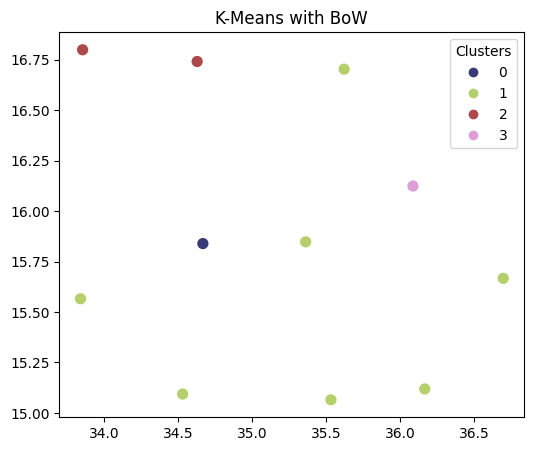

c:\Users\zhouz\miniforge3\envs\cpsc330-fresh\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\zhouz\miniforge3\envs\cpsc330-fresh\lib\site-packages\umap\umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


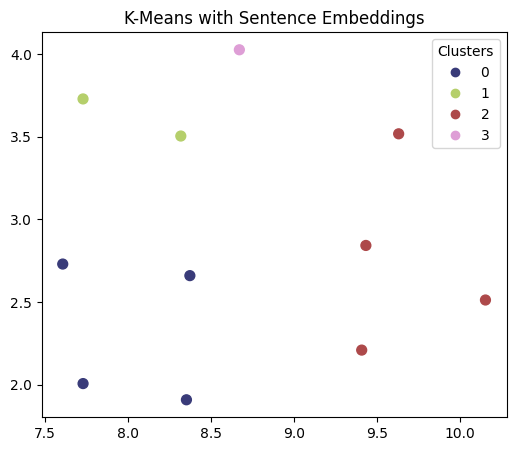

c:\Users\zhouz\miniforge3\envs\cpsc330-fresh\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\zhouz\miniforge3\envs\cpsc330-fresh\lib\site-packages\umap\umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


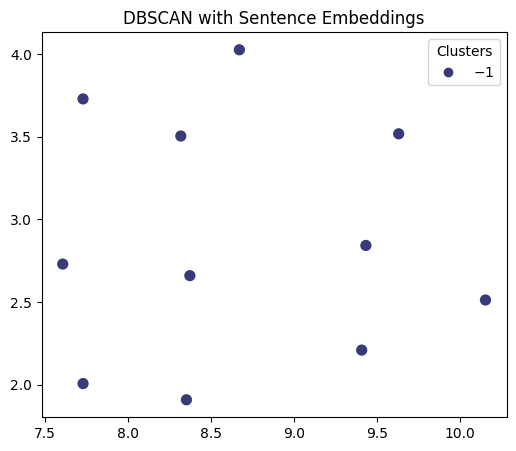

c:\Users\zhouz\miniforge3\envs\cpsc330-fresh\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\zhouz\miniforge3\envs\cpsc330-fresh\lib\site-packages\umap\umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


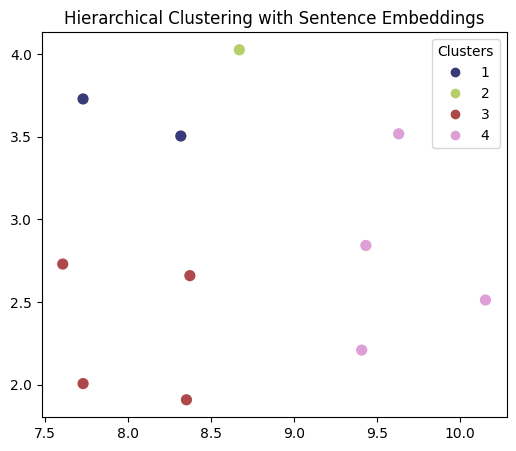

In [24]:
plot_umap_clusters(
    X.toarray(),
    kmeans_bow_labels,
    raw_texts=wiki_df["text"].tolist(),
    title="K-Means with BoW"
)

plot_umap_clusters(
    emb_sents,
    kmeans_emb_labels,
    raw_texts=wiki_df["text"].tolist(),
    title="K-Means with Sentence Embeddings"
)

plot_umap_clusters(
    emb_sents,
    dbscan_emb_labels,
    raw_texts=wiki_df["text"].tolist(),
    title="DBSCAN with Sentence Embeddings",
    ignore_noise=False
)

plot_umap_clusters(
    emb_sents,
    hier_emb_labels,
    raw_texts=wiki_df["text"].tolist(),
    title="Hierarchical Clustering with Sentence Embeddings"
)

<!-- END QUESTION -->

<br><br><br><br>

## Exercise 2: [Food.com](https://www.food.com/) recipes 
<hr>

Now that we have applied document clustering on a toy corpus, let's move to a more realistic corpus. 

In the lecture, we worked on an activity of manually clustering food items and discussed challenges associated with it. We also applied different clustering algorithms to cluster food images. We'll continue this theme of clustering food items in this lab. But instead of images we will cluster textual description of food items, i.e., recipe names.   

In this assignment, we will work with a sample of [Kaggle's Food.com recipes corpus](https://www.kaggle.com/shuyangli94/food-com-recipes-and-user-interactions). This corpus contains 180K+ recipes and 700K+ recipe reviews. In this lab, we'll only focus on recipes and **not** on reviews. The recipes are present in `RAW_recipes.csv`. Our goal is to find categories or groupings of recipes from this corpus based on their names. 

**Your tasks:**

- Download [`RAW_recipes.csv`](https://www.kaggle.com/shuyangli94/food-com-recipes-and-user-interactions?select=RAW_recipes.csv) and put it under the `data` directory in the homework folder. 
- Run the code below. The dataset is quite large, and in this assignment, for speed, you will work with a sample of the dataset. The function `get_recipes_sample` below carries out some preliminary preprocessing and returns a sample of the recipes with most frequent tags. 

> *Note: Depending upon the capacity of your computer, feel free to increase or decrease the size of this sample by changing the value for `n_tags`. If you decide to go with a different value of `n_tags`, state it clearly in Exercise 2.1 so that the grader knows about it.* 

In [25]:
orig_recipes_df = pd.read_csv("data/RAW_recipes.csv")
orig_recipes_df.shape

(231637, 12)

In [26]:
def get_recipes_sample(orig_recipes_df, n_tags=300, min_len=5):
    orig_recipes_df = orig_recipes_df.dropna()  # Remove rows with NaNs.
    orig_recipes_df = orig_recipes_df.drop_duplicates(
        "name"
    )  # Remove rows with duplicate names.
    # Remove rows where recipe names are too short (< 5 characters).
    orig_recipes_df = orig_recipes_df[orig_recipes_df["name"].apply(len) >= min_len]
    # Only consider the rows where tags are one of the most frequent n tags.
    first_n = orig_recipes_df["tags"].value_counts()[0:n_tags].index.tolist()
    recipes_df = orig_recipes_df[orig_recipes_df["tags"].isin(first_n)]
    return recipes_df

In [27]:
recipes_df = get_recipes_sample(orig_recipes_df)
recipes_df.shape

(9100, 12)

In [28]:
recipes_df["name"]

42        i yam what i yam  muffins    
101       to your health  muffins      
129       250 00 chocolate chip cookies
138       lplermagronen                
163       california roll   salad      
                   ...                 
231430    zucchini wheat germ cookies  
231514    zucchini blueberry bread     
231547    zucchini salsa burgers       
231596    zuppa toscana                
231629    zydeco salad                 
Name: name, Length: 9100, dtype: object

<br><br>

**In the rest of the homework, we will use `recipes_df` above, which is a subset of the original dataset.** 

<br><br>

<!-- BEGIN QUESTION -->

<div class="alert alert-info">
    
### 2.1 Longest and shorter recipe names 
rubric={points:2}

**Your tasks:**

1. Print the shortest and longest recipe names (length in terms of number of characters) from `recipes_df`. If there is more than one recipe with the same shortest/longest length, store **one** of them in `shortest_recipe` and/or `longest_recipe` as a **string**.

</div>

<div class="alert alert-warning">

Solution_2.1
    
</div>

_Points:_ 2

In [29]:
shortest_recipe = None
longest_recipe = None

name_lengths = recipes_df["name"].apply(len)

shortest_recipe = recipes_df.loc[name_lengths.idxmin(), "name"]
longest_recipe = recipes_df.loc[name_lengths.idxmax(), "name"]

print("Shortest recipe:", shortest_recipe)
print("Longest recipe:", longest_recipe)

Shortest recipe: bread
Longest recipe: baked tomatoes with a parmesan cheese crust and balsamic drizzle


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

<div class="alert alert-info">
    
### 2.2 More EDA
rubric={points:2}

**Your tasks:**
1. Create a word cloud for the recipe names. You can use [the `wordcloud` package](https://github.com/amueller/word_cloud) for this, which you will have to install in the course environment.
```
> conda activate cpsc330
> conda install -c conda-forge wordcloud
```

</div>

<div class="alert alert-warning">

Solution_2.2
    
</div>

_Points:_ 2

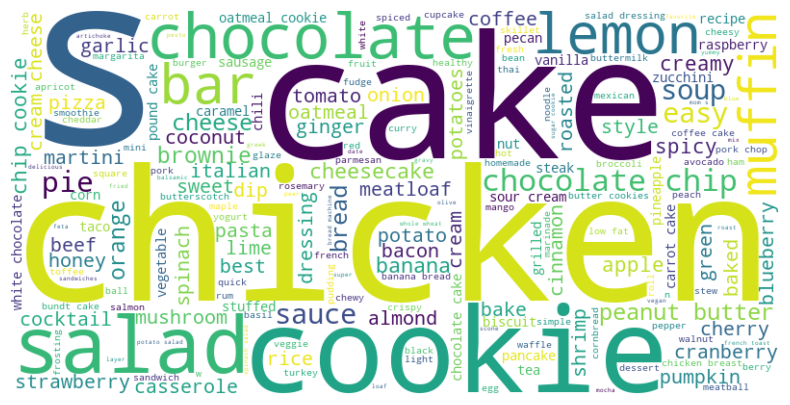

In [30]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(recipes_df["name"])

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

<div class="alert alert-info">

### 2.3 Representing recipe names
rubric={points:3}

The next step is creating a representation of recipe names. 

**Your tasks:**

1. Similar to Exercise 1, create sentence embedding representation of recipe names (`name` column in `recipes_df`).  For the rest of the homework, we'll stick to the sentence embedding representation of recipe names.


> You might have to convert the recipe names to a list (`recipes_df["name"].tolist()`) for the embedder to work
> *If you create a dataframe with sentence embedding representation, set the index to `recipes_df.index` so that the indices match with the indices of the sample we are working with.*  
> **This might take a while to run.**

</div>

<div class="alert alert-warning">

Solution_2.3
    
</div>

_Points:_ 3

In [31]:
embeddings = None





embeddings = embedder.encode(recipes_df["name"].tolist())
embeddings_df = pd.DataFrame(embeddings, index=recipes_df.index)

embeddings_df

,0,1,2,3,4,5,6,7,8,9,...,374,375,376,377,378,379,380,381,382,383
42,0.019592,-0.088336,0.072677,-0.034575,-0.048741,-0.049801,0.175334,-0.055191,0.020301,0.019828,...,0.063293,-0.067171,0.087500,-0.061550,0.039297,-0.050147,0.027708,0.056843,0.056152,-0.122506
101,-0.000567,-0.011825,0.073199,0.058176,0.031688,-0.015428,0.168134,0.000466,0.033078,-0.013923,...,-0.012926,-0.015949,0.031315,-0.059074,0.014143,-0.047270,0.007844,0.035501,0.076061,-0.078119
129,-0.022604,0.065034,-0.033065,0.014450,-0.105039,-0.050559,0.100076,0.022929,-0.037398,0.011857,...,0.007971,-0.019165,0.004935,0.009005,0.000919,-0.040078,0.008650,-0.075781,-0.083477,-0.123240
138,-0.066915,0.025988,-0.087689,-0.006847,-0.012861,0.049035,0.035351,0.124966,-0.011697,-0.050179,...,-0.042345,-0.005794,-0.031800,0.120664,-0.057335,-0.077068,0.001653,-0.048223,0.116455,0.021789
163,-0.007068,-0.007308,-0.026629,-0.004153,-0.052810,0.011126,0.024000,-0.036994,0.023526,-0.046870,...,-0.018432,0.051918,0.036101,-0.035312,0.005817,0.101802,-0.063171,-0.007917,0.089744,0.006997
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231430,-0.036366,0.087173,-0.039641,0.002705,0.097142,-0.075385,0.068207,0.010435,-0.069214,0.010464,...,0.050988,-0.064541,0.090829,-0.004570,0.079109,0.019663,-0.058483,-0.048723,0.019152,-0.012266
231514,-0.052718,0.008980,-0.046014,0.030194,0.005201,0.009964,-0.006760,0.030238,-0.031474,0.024632,...,0.075467,0.000967,0.085033,-0.006520,0.031094,0.072901,-0.094975,-0.052466,-0.003300,-0.006991
231547,-0.080801,0.004295,-0.044325,0.038308,-0.030125,-0.063566,0.004788,0.004822,0.015525,-0.040094,...,0.066642,0.016605,0.096211,-0.023969,0.045752,0.017091,-0.062939,-0.016950,0.012060,0.039776
231596,-0.060801,0.111672,-0.108755,0.052323,-0.099851,-0.027532,0.084190,-0.004861,0.002891,0.013943,...,0.038082,-0.014214,0.048392,0.050377,0.015281,0.106766,0.032009,0.020113,0.004977,-0.005828


<!-- END QUESTION -->

<br><br><br><br>

## Exercise 3: Clustering recipe names
<hr>

In this exercise you'll cluster recipe names with some of the clustering algorithms we have seen in class. This will also involve making some attempts to pick reasonable hyperparameter values for each clustering method based on the quality of the resulting clusters. For example, for KMeans, you need to specify the number of clusters in advance, which is often challenging on real-world datasets. For DBSCAN, you need to pick appropriate `eps` and `min_samples`. For hierarchical clustering, you need to pick a suitable linkage criterion, distance metric, and prune the tree so that it's possible to visualize and interpret it. 

Here are some methods which may help you with picking reasonable values for the hyperparameters. 
- Visualize the Elbow plot (KMeans). 
- Visualize Silhouette plots. 
- Visualize resulting clusters using `plot_umap_clusters` function from Exercise 1. 
- Sample some recipes from each cluster, manually inspect whether there are coherent semantic themes. (For this, you may use the function `print_clusters` given below.) 
        
> You may use the [`yellowbrick`](https://www.scikit-yb.org/en/latest/) package for visualizing the Elbow plot and the Silhouette plots. You can intall it with

```conda install -c districtdatalabs yellowbrick```

**Note that the process of picking reasonable hyperparameter values will be exploratory, iterative, and will involve manual inspection and judgment, as there is no ground truth to verify how well the model is doing. In your solutions, please do not include everything you try. Only present the results of the most informative trials. Add a narrative to your answer so that it's easy for the grader to follow your choices and reasoning.** 

In [32]:
def print_clusters(recipes_df, cluster_labels, n_recipes=10, replace=False, random_state=None):
    """
    Given recipes_df containing recipe names and cluster assignment (labels), 
    sample and print n_recipes recipes per cluster. 

    Parameters
    -----------
    recipe_df : pandas dataframe 
        recipes dataframe containing recipe names in the "name" column
    cluster_labels : ndarray or a list
        cluster labels for each row in recipes_df 
    n_recipes : int
        number of examples to sample from each cluster
    replace: bool
        replace flag to pass to the sampling of recipe names

    Returns
    -----------
    None
    """    
    
    grouped = (
        pd.DataFrame(
            {
                "name": recipes_df["name"],
                "cluster_label": cluster_labels,
            }
        )
        .sort_values("cluster_label")
        .groupby("cluster_label")    
    )
    
    for name, group in grouped:
        print(f"Cluster {name}")        
        print(("----------").format(""))        
        print("\n".join(group.sample(n_recipes, random_state=random_state, replace=replace)['name'].tolist()))
        print("\n\n")

<br><br>

<!-- BEGIN QUESTION -->

<div class="alert alert-info">
    
### 3.1 K-Means
rubric={points:6}

**Your tasks:**

1. Cluster recipe titles using KMeans. Make some attempts to determine the optimal number of clusters. 
2. Pick one or two best models and justify your choice.

</div>

<div class="alert alert-warning">

Solution_3.1
    
</div>

_Points:_ 6

_Type your answer here, replacing this text._

In [33]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=12, random_state=42)
kmeans_labels = kmeans.fit_predict(embeddings)

In [34]:
print_clusters(recipes_df, kmeans_labels, n_recipes=10, random_state=42)

Cluster 0
----------
eliz s mushroom risotto
greet the sun breakfast pizzas
stuffed shells bolognese
creamy herb mashed potatoes
mast o musir   persian yogurt dip with shallots
red potatoes with a flare
italian spinach   pasta bake
gorgonzola focaccia
red pepper  feta and garlic hummus
roast potatoes with lemon and coriander



Cluster 1
----------
butter chocolate bliss martini
peanut butter finger bars
kellogg s frosted flakes good times bars
chocolate mint brownies
goldy bear s honey gingersnaps
oriental rice pudding with rhubarb
grilled beer braised bratwursts with cranberry pickle chutney
jam streusel bars
saskatoon berry jam
lemon and blueberry yogurt parfait  low fat



Cluster 2
----------
berry cherry banana shortcake
chillin  strawberry pie
drumstick cheesecake
lemon whoopie pies
white chocolate rhubarb swirled cheesecake
root beer pancakes
amaretto cheesecake bars
pumpkin hand pies
overnight pumpkin pecan waffles
chocolate fruitcake  non alcholic



Cluster 3
----------
cala

c:\Users\zhouz\miniforge3\envs\cpsc330-fresh\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


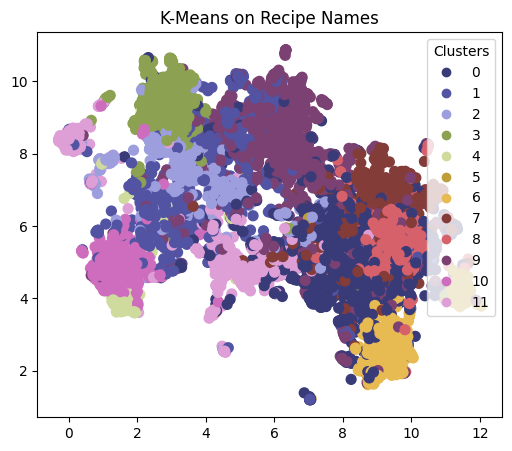

In [35]:
plot_umap_clusters(
    embeddings,
    kmeans_labels,
    raw_texts=recipes_df["name"].tolist(),
    title="K-Means on Recipe Names"
)

In [36]:
for k in [8, 10, 12, 15, 20]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(embeddings)
    print(f"k = {k}")
    print_clusters(recipes_df, labels, n_recipes=5, random_state=42)

k = 8
Cluster 0
----------
apricot crumble squares
spice and herb marinade
gluten free tropical rice
made from scratch broccoli cornbread
southwest style potato corn chowder



Cluster 1
----------
isle of coconut
texas lizzies
spicy gingerman cocktail
sinful bars
truly the best key lime pie martini



Cluster 2
----------
brunch egg burritos
red pepper biscuits
buttermilk blueberry pancakes
california white bread
texas roadhouse buttery dinner rolls with cinnamon butter



Cluster 3
----------
heavenly white cake
german chocolate cake
fresh cran apple cake
butter rum cake   from scratch
the best louisiana crunch cake ever



Cluster 4
----------
nestle toll house mini morsel cookies
kairos chocolate chip cookies
dr  cookie peanut butter squares
the barefoot contessa s ultimate ginger cookies
drop ginger cakes  cookies



Cluster 5
----------
creamed chicken with mushrooms  pearl onions   sherry
apple and onion chicken
aunt jo s crescent chicken rolls
chicken noodle bowl
takeout lemon 

In [37]:
...

Ellipsis

<!-- END QUESTION -->

<br><br><br><br>

<!-- BEGIN QUESTION -->

<div class="alert alert-info">
    
### 3.2 DBSCAN
rubric={points:6}

**Your tasks:**

1. Cluster recipe names using `DBSCAN` with `metric="cosine"`. Make some attempts to tune the  hyperparameters `eps` and `min_samples`.

</div>

<div class="alert alert-warning">

Solution_3.2
    
</div>

_Points:_ 6

I applied DBSCAN with cosine distance and tried different values of eps and min_samples. 
With small eps values, most recipes were labeled as noise. 
After increasing eps, some clusters appeared but the results were still uneven. 
Overall, DBSCAN was harder to tune compared to KMeans.

In [38]:
from sklearn.cluster import DBSCAN
import numpy as np

for eps in [0.15, 0.2, 0.25, 0.3]:
    for min_samples in [3, 5, 10]:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric="cosine")
        labels = dbscan.fit_predict(embeddings)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)
        print(f"eps={eps}, min_samples={min_samples}, clusters={n_clusters}, noise={n_noise}")

eps=0.15, min_samples=3, clusters=136, noise=8259
eps=0.15, min_samples=5, clusters=30, noise=8687
eps=0.15, min_samples=10, clusters=4, noise=8924
eps=0.2, min_samples=3, clusters=215, noise=6958
eps=0.2, min_samples=5, clusters=68, noise=7760
eps=0.2, min_samples=10, clusters=12, noise=8497
eps=0.25, min_samples=3, clusters=164, noise=5130
eps=0.25, min_samples=5, clusters=61, noise=5968
eps=0.25, min_samples=10, clusters=19, noise=7059
eps=0.3, min_samples=3, clusters=85, noise=3201
eps=0.3, min_samples=5, clusters=25, noise=3757
eps=0.3, min_samples=10, clusters=11, noise=4820


In [39]:
dbscan = DBSCAN(eps=0.25, min_samples=5, metric="cosine")
dbscan_labels = dbscan.fit_predict(embeddings)

print_clusters(recipes_df, dbscan_labels, n_recipes=10, replace=True, random_state=42)

Cluster -1
----------
best ever zatarain s jambalaya
mushy peas
mini orange pochettes by melissa d arabian
mini bbq sausage tartlets
greek style marinated mushrooms
easy smoked turkey sausage cassoulet
orange pumpkin scone cookie cut outs
bacon and red potato bake
roasted red potatoes with shallots and fresh herbs
kahlua   cognac



Cluster 0
----------
buttermilk ranch dressing
honey and garlic dressing 2
raspberry vinaigrette salad dressing
tropical lime chicken
basil garlic vinaigrette
another garlic chicken
caterer s basic french salad dressing
red leaf salad
taylor s landing spinach salad with honey mustard dressing
easy honey french dressing



Cluster 1
----------
new york deli style cheesecake
new york cheesecake
cheesecake supreme
new york deli style cheesecake
cheater s new york style cheesecake
philadelphia oreo cheesecake
cheesecake supreme
cheesecake supreme
new york deli style cheesecake
new york  style crustless cheesecake



Cluster 2
----------
potato  leek  and roaste

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

<div class="alert alert-info">
    
### 3.3 Hierarchical clustering
rubric={points:6}

**Your tasks:**

1. Try hierarchical clustering with `metric="cosine"` on this problem. Show a dendrogram by using a suitable truncation method. 
2. Create flat clusters by cutting the tree at the appropriate level. 

> *Note: Try orientation="left" of `dendrogram` for better readability of the dendrogram.*

</div>

<div class="alert alert-warning">

Solution_3.3
    
</div>

_Points:_ 6

_Type your answer here, replacing this text._

In [40]:
from scipy.cluster.hierarchy import linkage

Z = linkage(embeddings, method="complete", metric="cosine")

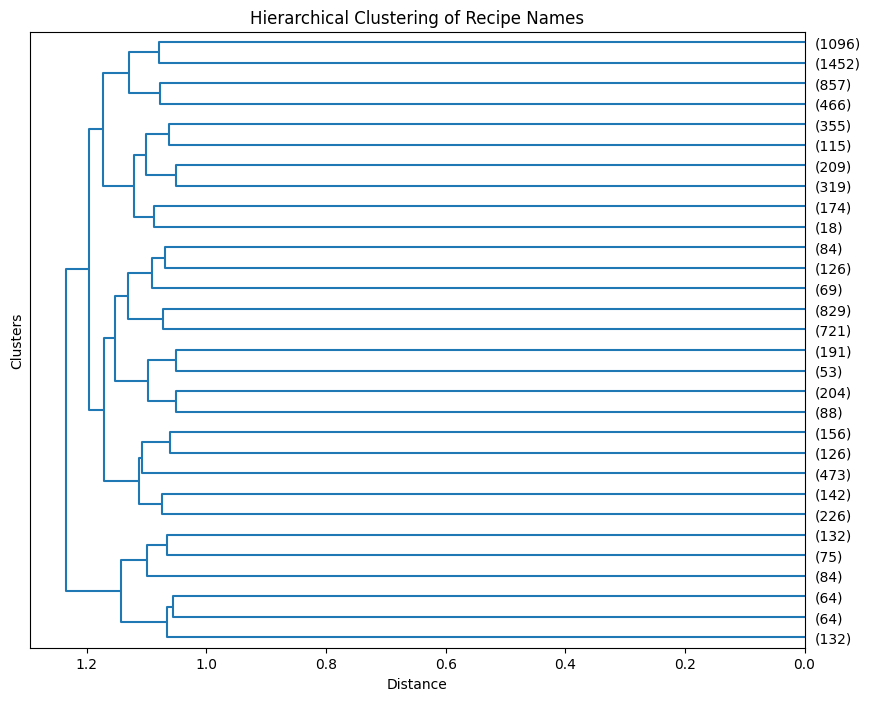

In [41]:
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

dendrogram(
    Z,
    truncate_mode="lastp",
    p=30,
    orientation="left"
)

plt.title("Hierarchical Clustering of Recipe Names")
plt.xlabel("Distance")
plt.ylabel("Clusters")

plt.show()

In [42]:
from scipy.cluster.hierarchy import fcluster

hier_labels = fcluster(Z, t=12, criterion="maxclust")

In [43]:
print_clusters(recipes_df, hier_labels, n_recipes=5, random_state=42)

Cluster 1
----------
matcha green tea cookies
flaming angry dragon
fat santa s
new orleans hurricane
old fashioned



Cluster 2
----------
grapefruit cosmo
kato s  chocolate hazelnut delight  torte
hazelnut torte
lasagna with artichokes no cook noodles
pastel de tres leches



Cluster 3
----------
simple spicy corn dip
tropical romaine salad with pineapple vinaigrette
mother s bavarian pot roast
chocolate irish cream cheesecake
julia child s master recipe for beef bourguignon  in red wine



Cluster 4
----------
van nuys  aka dirty margarita
hard strawberry lemonade
margarita   on the rocks
purple margarita
pockets of lemon cake



Cluster 5
----------
lion s head meatballs
apple strips
strawberry cheese ball
white cheddar  apple  and bacon cheesecake
homesteader s fireweed honey



Cluster 6
----------
quinoa pudding with apricots and pistachios
red snapper  adult drink
lactose free  indian curry
fusilli with mushrooms and chard
pink prozac  cocktail



Cluster 7
----------
greek toma

c:\Users\zhouz\miniforge3\envs\cpsc330-fresh\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


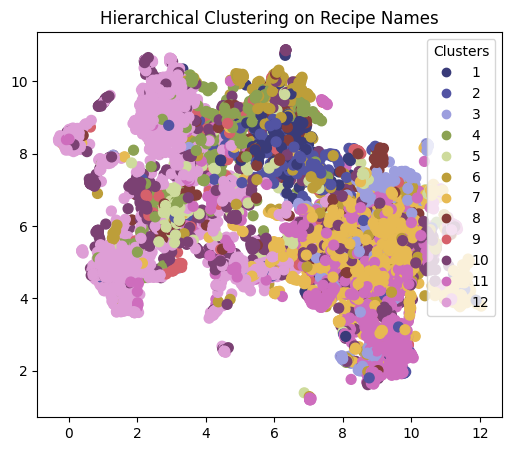

In [44]:
plot_umap_clusters(
    embeddings,
    hier_labels,
    raw_texts=recipes_df["name"].tolist(),
    title="Hierarchical Clustering on Recipe Names"
)

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

<div class="alert alert-info">
    
### 3.4 Manual interpretation of clusters
rubric={points:6}

**Your tasks:**

1. Label the topics/themes you see in the clusters created by different clustering methods.  
2. Do you see a common theme across clusters created by different clustering methods? Do you see any differences between the clusters created by different clustering methods?

</div>

<div class="alert alert-warning">

Solution_3.4
    
</div>

_Points:_ 6

Some clusters looks like similar recipe types. For example dessert recipes like brownies or bars are often grouped together, while other clusters have pasta, rice or vegetable dishes.

There are some common themes across methods, like sweet foods vs main dishes. But the clusters are not exactly same. K-means gives more balanced groups, DBSCAN has many noise points, and hierarchical clustering shows structure but still mix some recipes.

Overall clustering works ok but recipe names are short so sometimes the grouping is not very clear.

<!-- END QUESTION -->

<br><br><br><br>

Before submitting your assignment, please make sure you have followed all the instructions in the Submission Instructions section at the top. 

Here is a quick checklist before submitting: 

- [ ] Restart kernel, clear outputs, and run all cells from top to bottom.  
- [ ] `.ipynb` file runs without errors and contains all outputs.  
- [ ] Only `.ipynb` and required output files are uploaded (no extra files).  
- [ ] Execution numbers start at **1** and are in order.  
- [ ] If `.ipynb` is too large and doesn't render on Gradescope, also upload a PDF/HTML version.  
- [ ] Reviewed the [CPSC 330 homework instructions](https://ubc-cs.github.io/cpsc330-2025W2/docs/homework-instructions).

![](img/eva-well-done.png)